In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/fish/Fish_Dataset/Fish_Dataset'
model_algo="vgg16"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [6]:
valid_size

3600

In [7]:
train_size

12600

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.1750265144568587,train_accu=0.9342857142857143
Epoch=0,valid_loss=0.1974517991145452,valid_accu=0.9280555555555555
0
Epoch=1,train_loss=0.15507515954238082,train_accu=0.9413492063492064
Epoch=1,valid_loss=0.1616789924684498,valid_accu=0.9430555555555555
0
Epoch=2,train_loss=0.08249306278037173,train_accu=0.9720634920634921
Epoch=2,valid_loss=0.10704867525647084,valid_accu=0.9641666666666666
0
Epoch=3,train_loss=0.027932960825883563,train_accu=0.9901587301587301
Epoch=3,valid_loss=0.04998456690201743,valid_accu=0.98
0
Epoch=4,train_loss=0.0295185794856488,train_accu=0.9896825396825397
Epoch=4,valid_loss=0.05541241368537562,valid_accu=0.9805555555555555
0
Epoch=5,train_loss=0.05260849810382795,train_accu=0.9827777777777778
Epoch=5,valid_loss=0.09006815753359762,valid_accu=0.9669444444444445
Epoch=6,train_loss=0.10537730680948626,train_accu=0.9677777777777777
Epoch=6,valid_loss=0.1404123009203209,valid_accu=0.9597222222222223
Epoch=7,train_loss=0.025201620939603476,tr

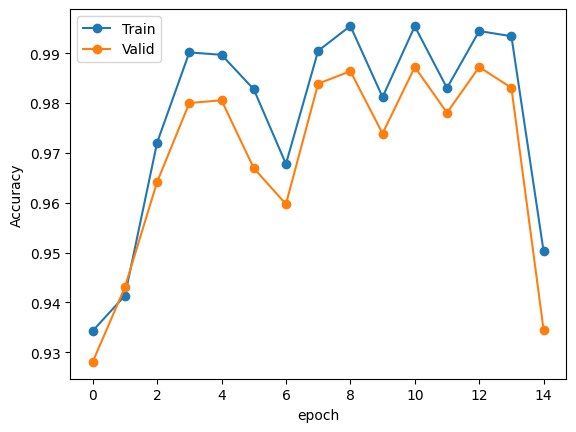

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_7.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.013399092907761409, 0.9948412698412699)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.04014696918644606, 0.9875)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=p
each_accu

Black Sea Sprat       1.000000
Gilt-Head Bream       0.992888
Hourse Mackerel       1.000000
Red Mullet            0.981349
Red Sea Bream         0.989331
Sea Bass              1.000000
Shrimp                0.997046
Striped Red Mullet    0.994310
Trout                 0.998566
dtype: float64

In [14]:
each_f1=2*p*r/(p+r)
each_f1

Black Sea Sprat       0.997159
Gilt-Head Bream       0.991125
Hourse Mackerel       0.999290
Red Mullet            0.988082
Red Sea Bream         0.992154
Sea Bass              0.998601
Shrimp                0.998521
Striped Red Mullet    0.989735
Trout                 0.998924
dtype: float64

In [15]:
# targetF=[]
# for top in top_positions:
#     targetF.append(top[0])
#     targetF.append(top[1])
# targetF    

In [16]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [17]:
targetF=[x  for x in each_f1.nsmallest(90).index.map(trainset.dataset.classess)]
targetF

[3, 7, 1, 4, 0, 6, 5, 8, 2]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('TandF')
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(60, 12540)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(43, 3557)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

Epoch=0,train_loss=0.005590003735435728,train_accu=0.9984920634920635
Epoch=0,valid_loss=0.10764801521984964,valid_accu=0.9872222222222222
0
Epoch=1,train_loss=0.0018828549342562461,train_accu=0.9993650793650793
Epoch=1,valid_loss=0.1447863578930466,valid_accu=0.9861111111111112
Epoch=2,train_loss=0.0034716657381128127,train_accu=0.9992063492063492
Epoch=2,valid_loss=0.17172198319116705,valid_accu=0.9852777777777778
Epoch=3,train_loss=0.0014272348285169843,train_accu=0.9998412698412699
Epoch=3,valid_loss=0.2092009173993389,valid_accu=0.9863888888888889
Epoch=4,train_loss=0.0057483437343279885,train_accu=0.9994444444444445
Epoch=4,valid_loss=0.22282913317513955,valid_accu=0.9858333333333333
4 Early stopping!


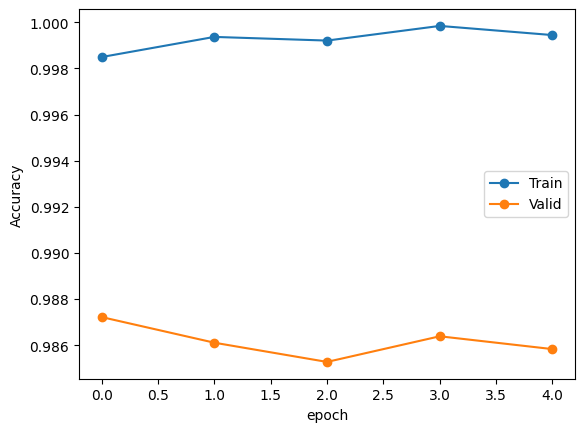

In [22]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [23]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.0014474135789506338,train_accu=0.9996810207336523
Epoch=0,valid_loss=0.007112203280929511,valid_accu=0.9977509136913129
0
Epoch=1,train_loss=0.0005441907528489773,train_accu=0.9997607655502392
Epoch=1,valid_loss=0.004598745400569168,valid_accu=0.9980320494798988
0
Epoch=2,train_loss=0.0002162053930568635,train_accu=1.0
Epoch=2,valid_loss=0.009964743412332904,valid_accu=0.9977509136913129
Epoch=3,train_loss=0.00023571177005547167,train_accu=0.9999202551834131
Epoch=3,valid_loss=0.009158869928220759,valid_accu=0.9983131852684847
0
Epoch=4,train_loss=0.0027747209004795144,train_accu=0.99896331738437
Epoch=4,valid_loss=0.01122533402458854,valid_accu=0.9969075063255552
Epoch=5,train_loss=0.0008678686771231781,train_accu=0.9996810207336523
Epoch=5,valid_loss=0.02223734914574222,valid_accu=0.9952206915940399
Epoch=6,train_loss=0.0005296100681653353,train_accu=0.9998405103668262
Epoch=6,valid_loss=0.017292803469522194,valid_accu=0.9966263705369693
Epoch=7,train_loss=0.0001

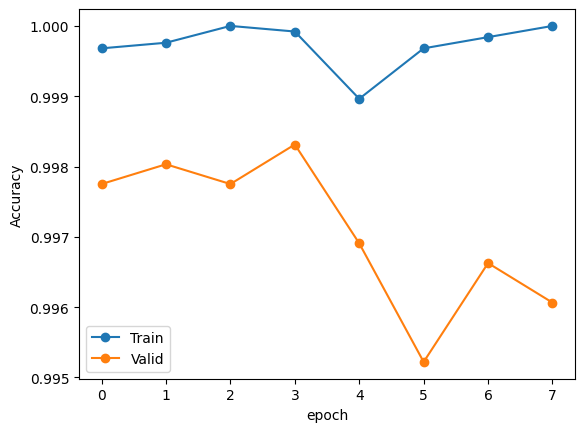

In [24]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.6687515338261922,train_accu=0.6666666666666666
Epoch=0,valid_loss=1.8674127916957057,valid_accu=0.46511627906976744
0
Epoch=1,train_loss=1.18895370165507,train_accu=0.7833333333333333
Epoch=1,valid_loss=1.5588245779968972,valid_accu=0.5116279069767442
0
Epoch=2,train_loss=0.8658634066581726,train_accu=0.7833333333333333
Epoch=2,valid_loss=1.3631072460218918,valid_accu=0.5581395348837209
0
Epoch=3,train_loss=0.6376695036888123,train_accu=0.8166666666666667
Epoch=3,valid_loss=1.3198163315307263,valid_accu=0.5581395348837209
Epoch=4,train_loss=0.45493126710255943,train_accu=0.8333333333333334
Epoch=4,valid_loss=1.2731147616408591,valid_accu=0.5813953488372093
0
Epoch=5,train_loss=0.4116308271884918,train_accu=0.8666666666666667
Epoch=5,valid_loss=1.3075963369635648,valid_accu=0.5813953488372093
Epoch=6,train_loss=0.3399341563383738,train_accu=0.8833333333333333
Epoch=6,valid_loss=1.3765604301940564,valid_accu=0.5813953488372093
Epoch=7,train_loss=0.2743625005086263,tr

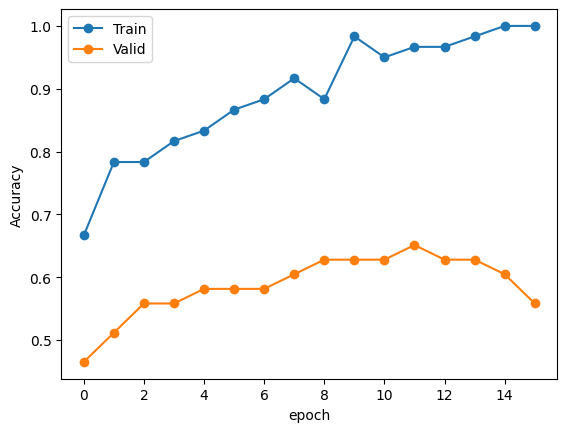

In [25]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [26]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.002276018176431997, 0.9993650793650793)

In [27]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.10764801521984964, 0.9872222222222222)

In [28]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0004152969050629882, 0.9997607655502392)

In [29]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.1533786192536354, 0.95)

In [30]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.00660675454286142, 0.9983131852684847)

In [31]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.3809193220249443, 0.627906976744186)

In [32]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.0006297851502910963, 0.9999206349206349)

In [33]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.029678096255263457, 0.9930555555555556, 43)

In [34]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.0010807281573892433, 0.9998412698412699, 72, 12528)

In [35]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.028549909739508952, 0.9944444444444445, 21, 3579)

In [36]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [37]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.013399,0.994841,0.040147,0.987500
1,Model_Decision,0.002276,0.999365,0.107648,0.987222
2,Model_T,0.000415,0.999761,0.006607,0.998313
3,Model_F,0.153379,0.950000,1.380919,0.627907
4,Total_Model,0.001081,0.999841,0.028550,0.994444
5,Total_Model_with_perfect_decision,0.000630,0.999921,0.029678,0.993056


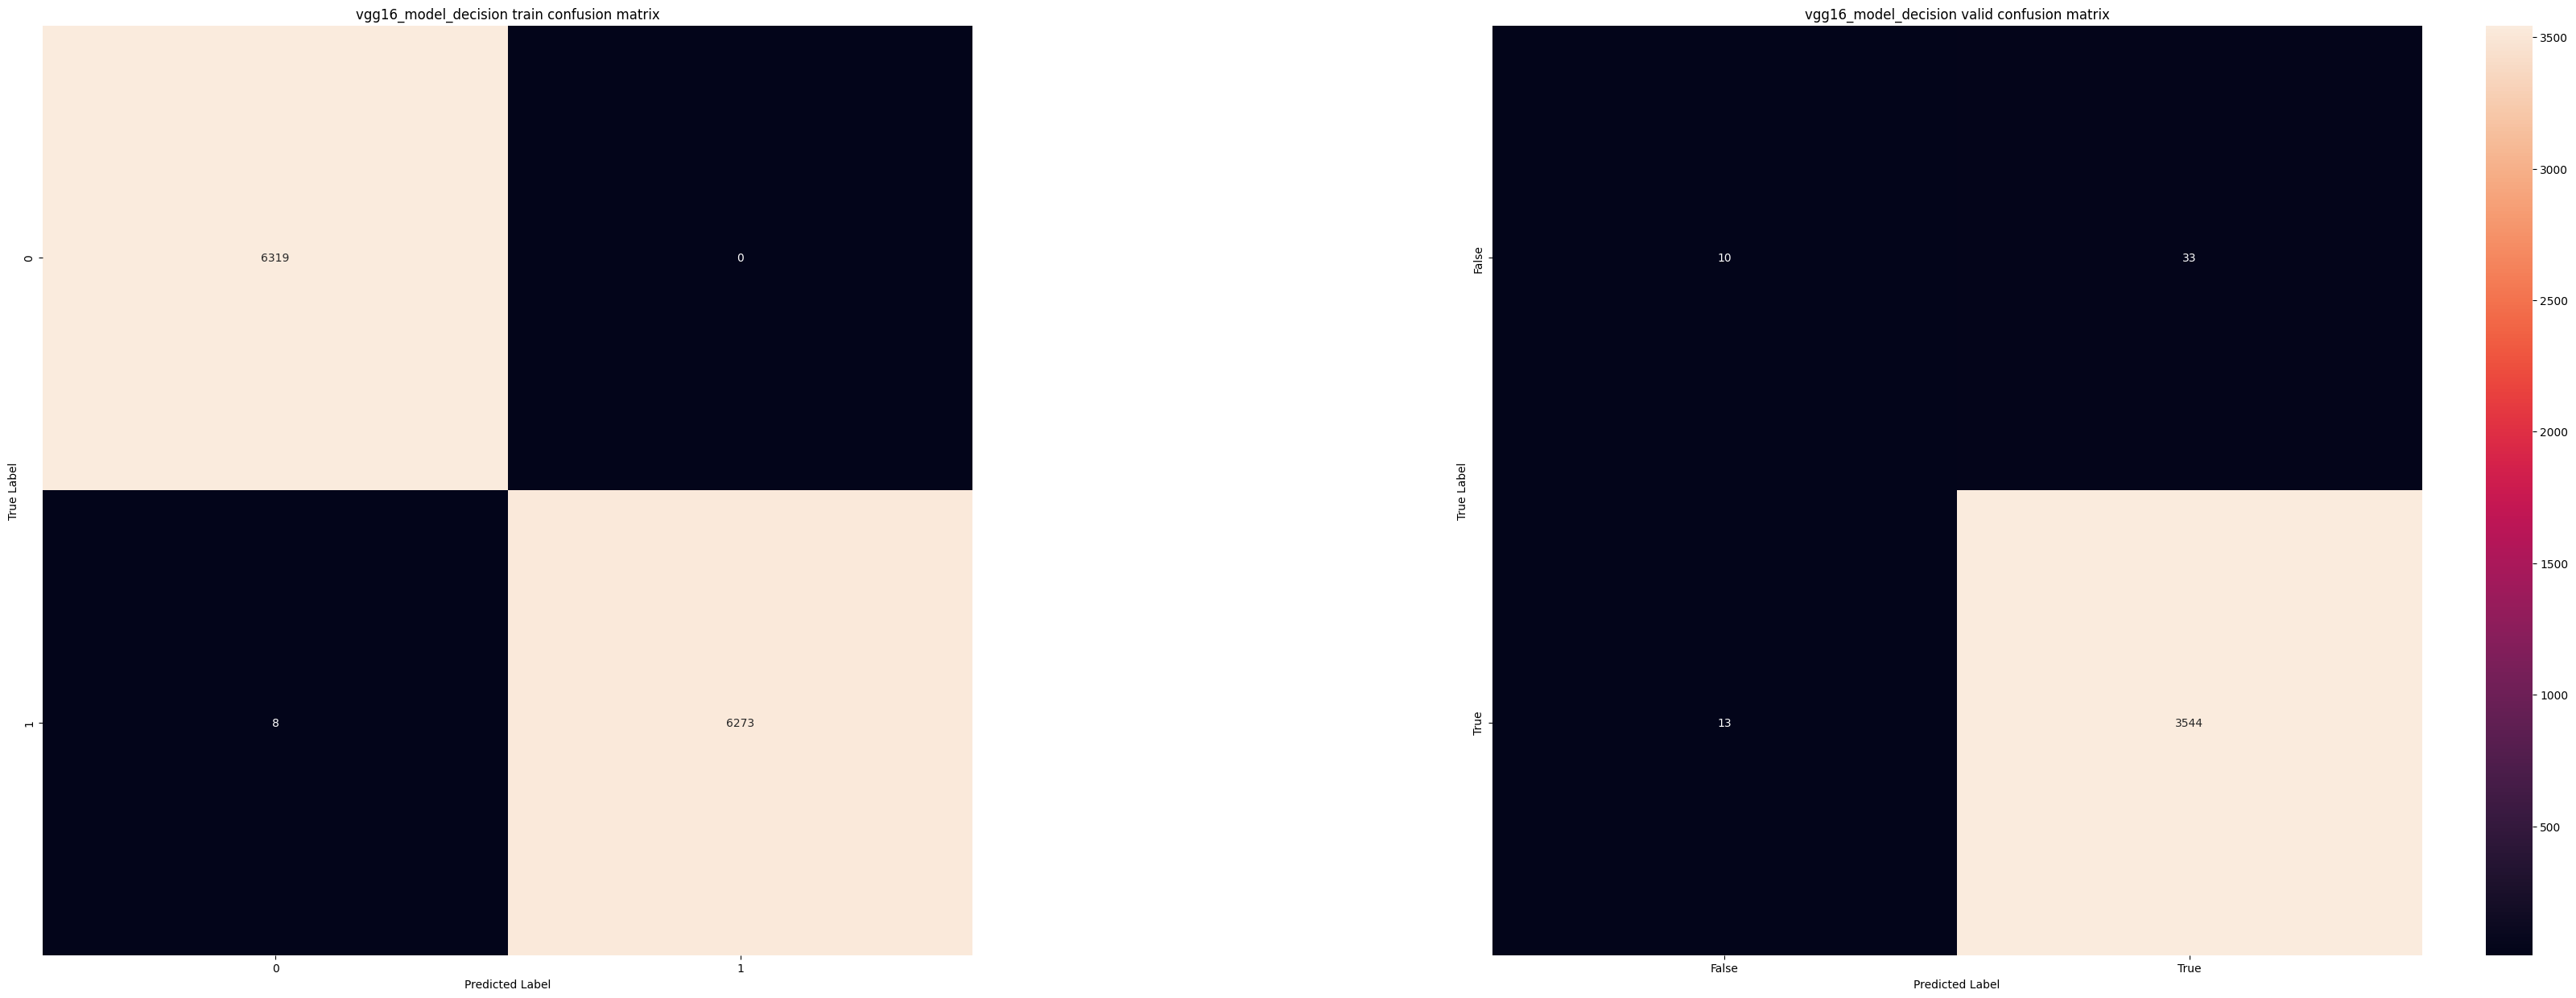

In [38]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

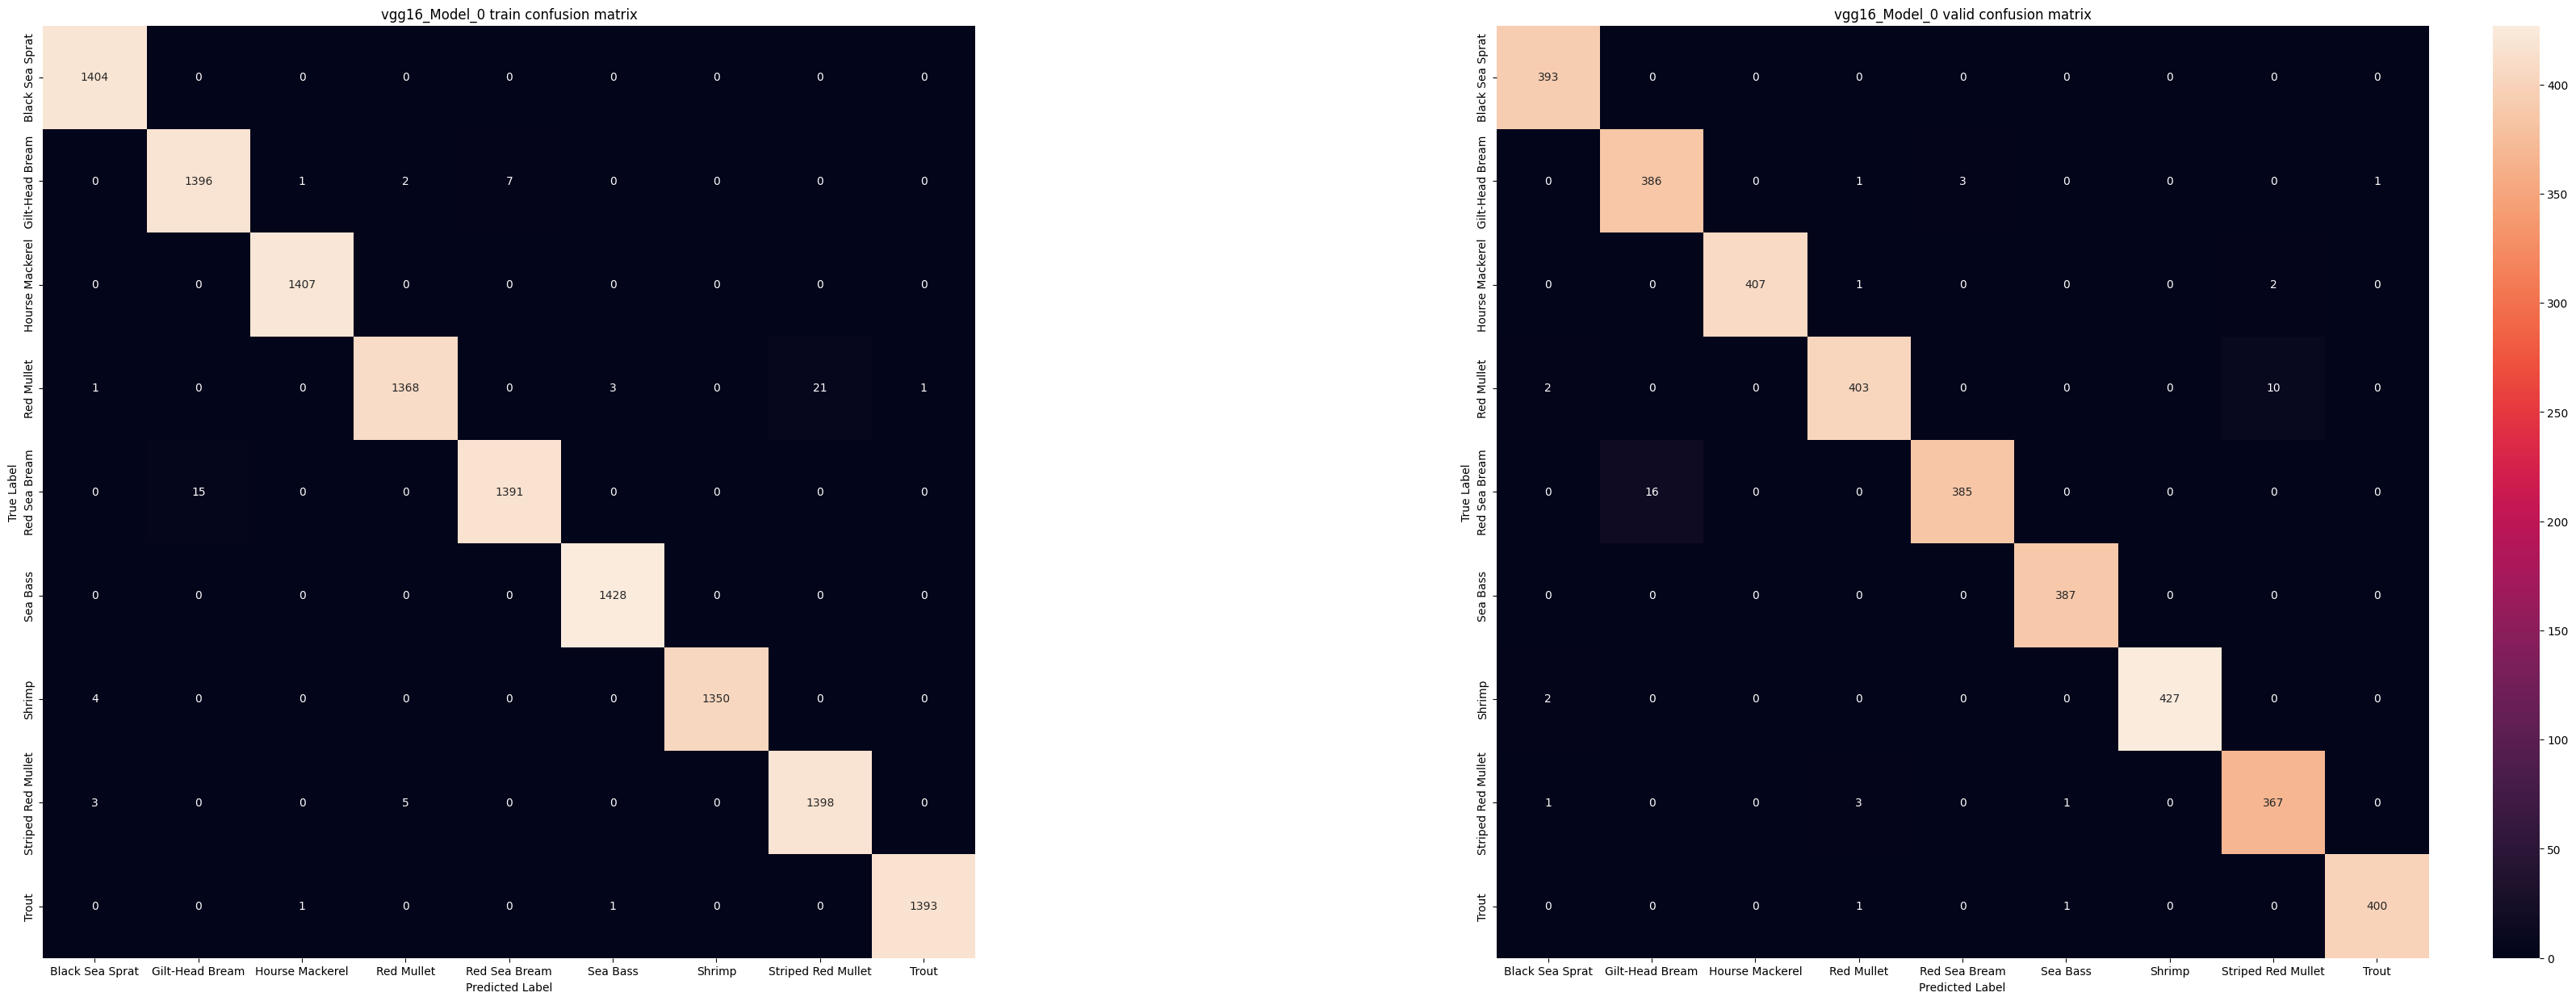

In [39]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

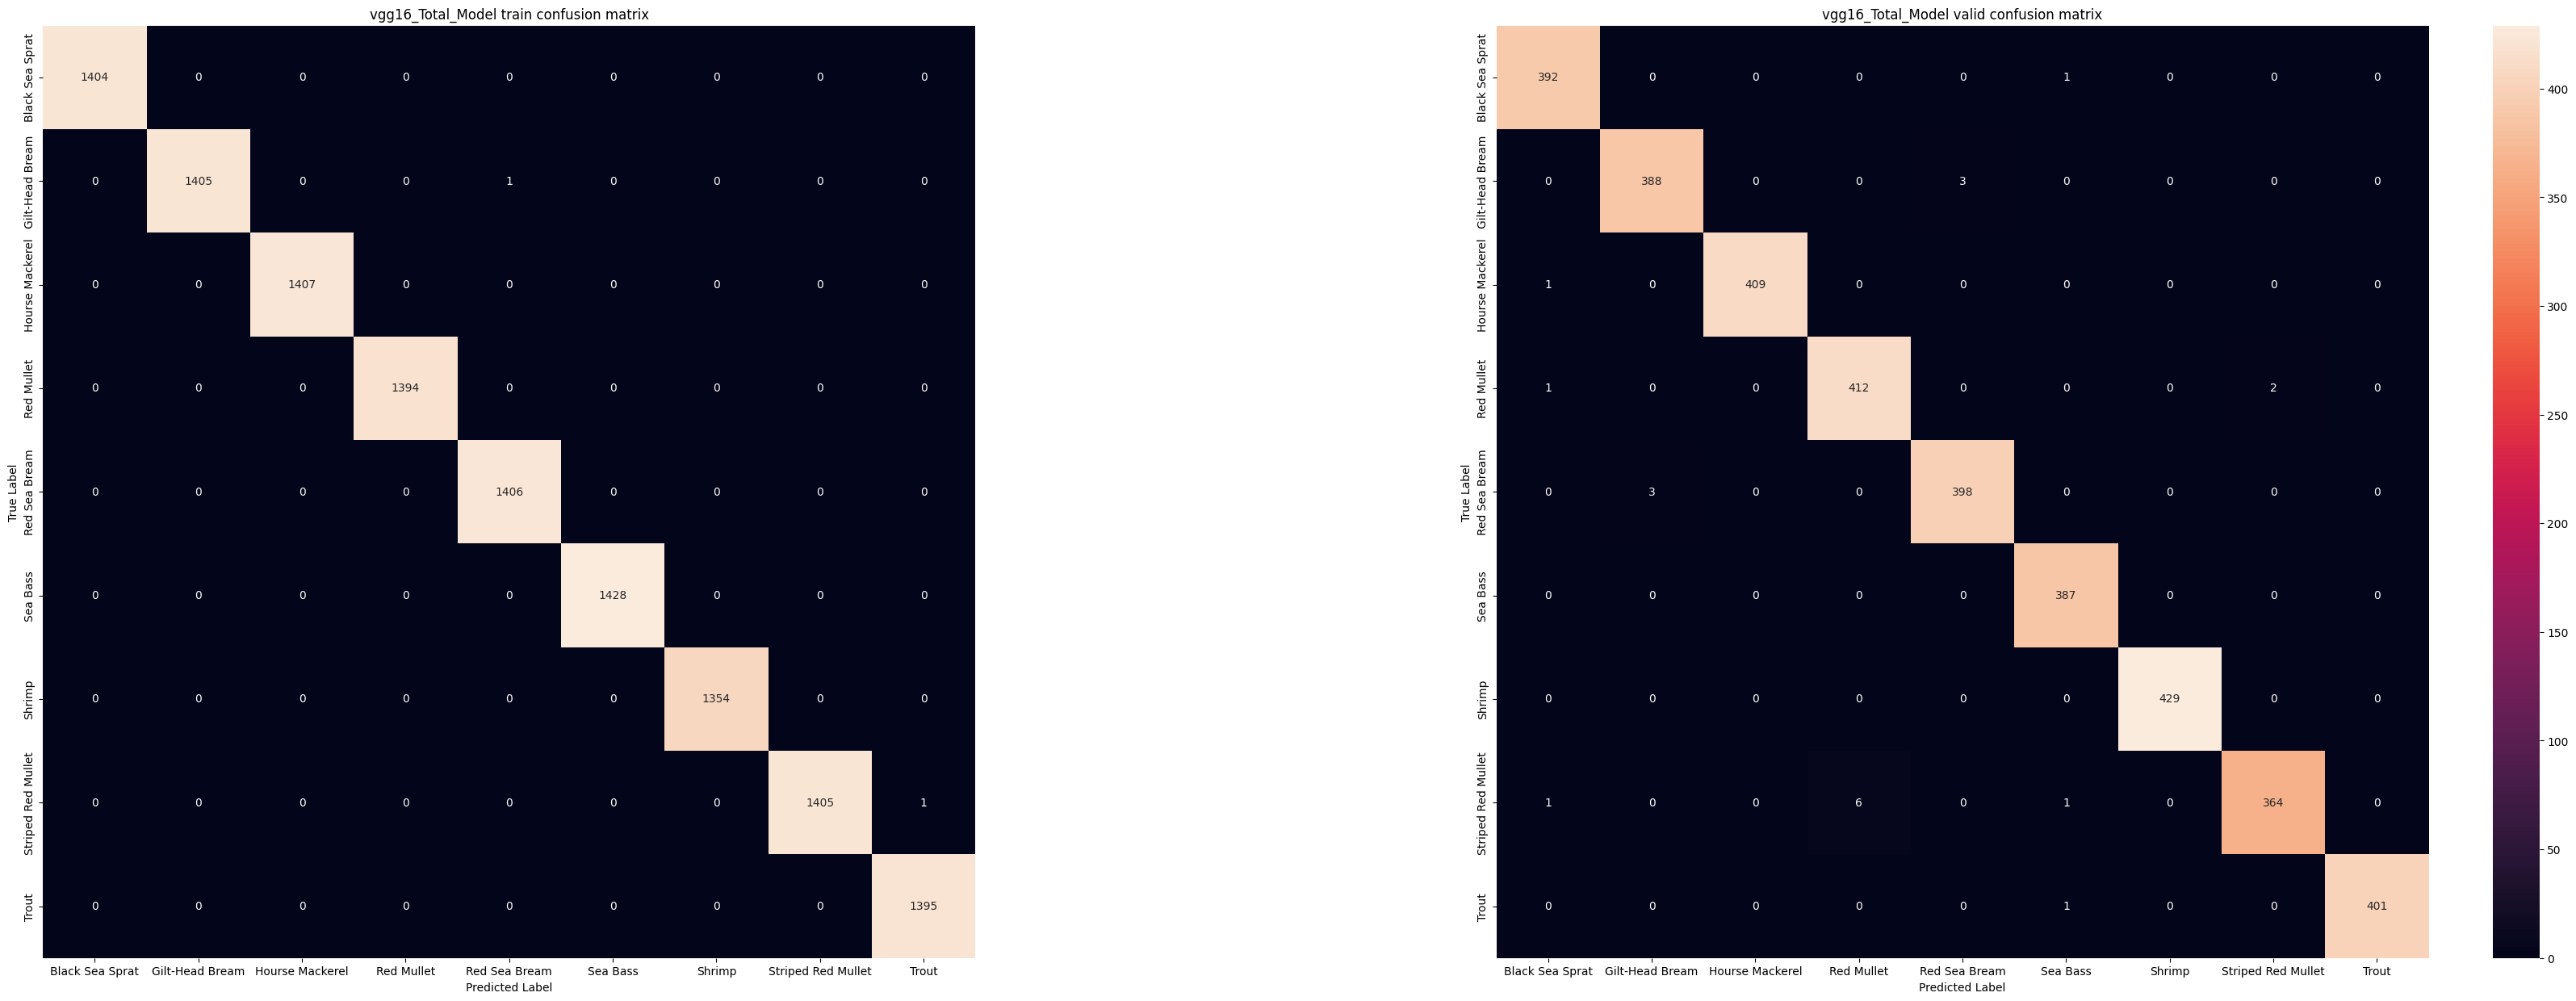

In [40]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

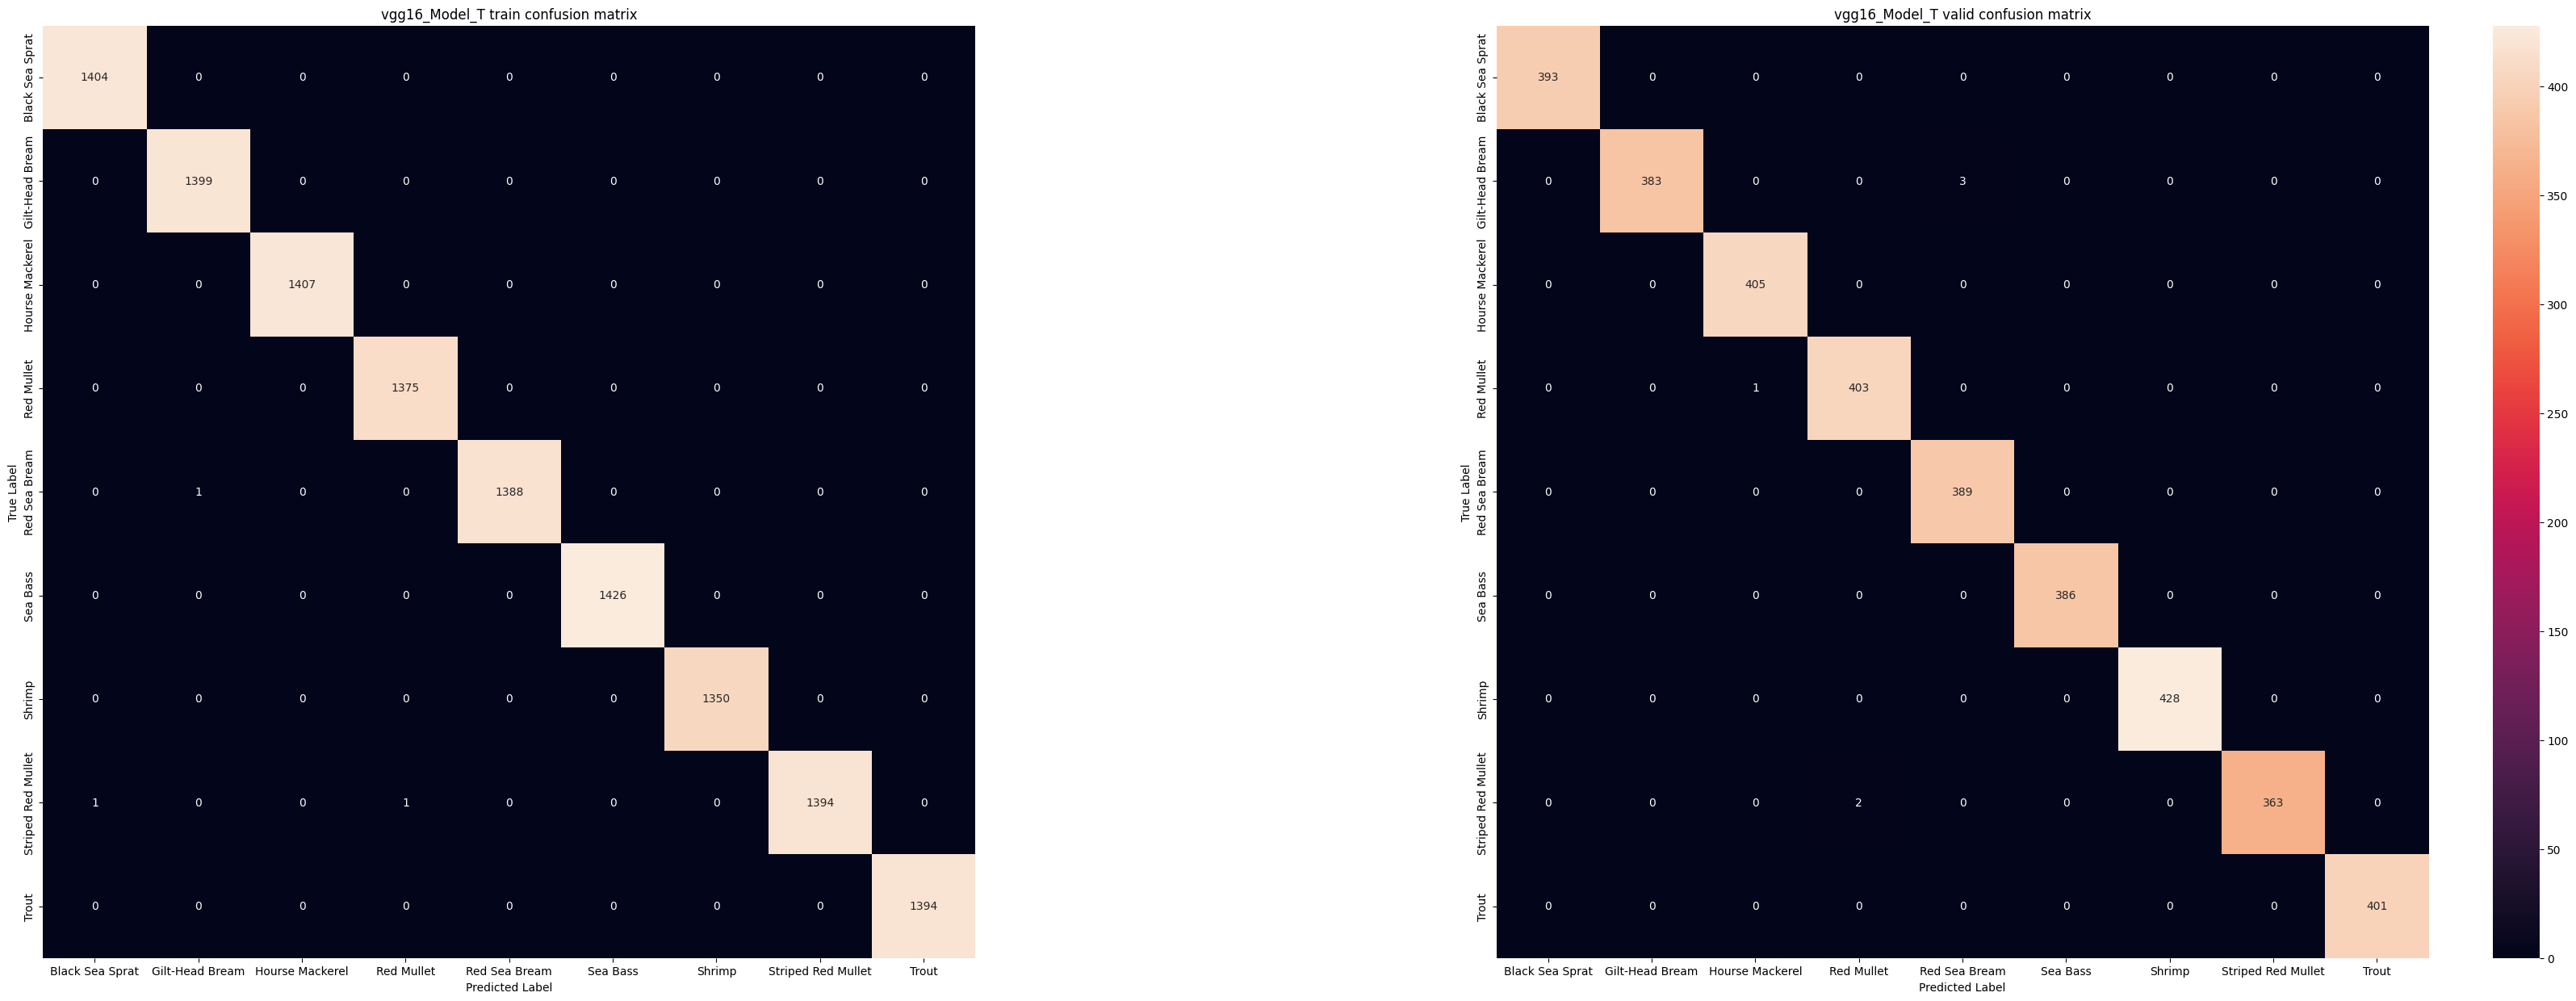

In [41]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

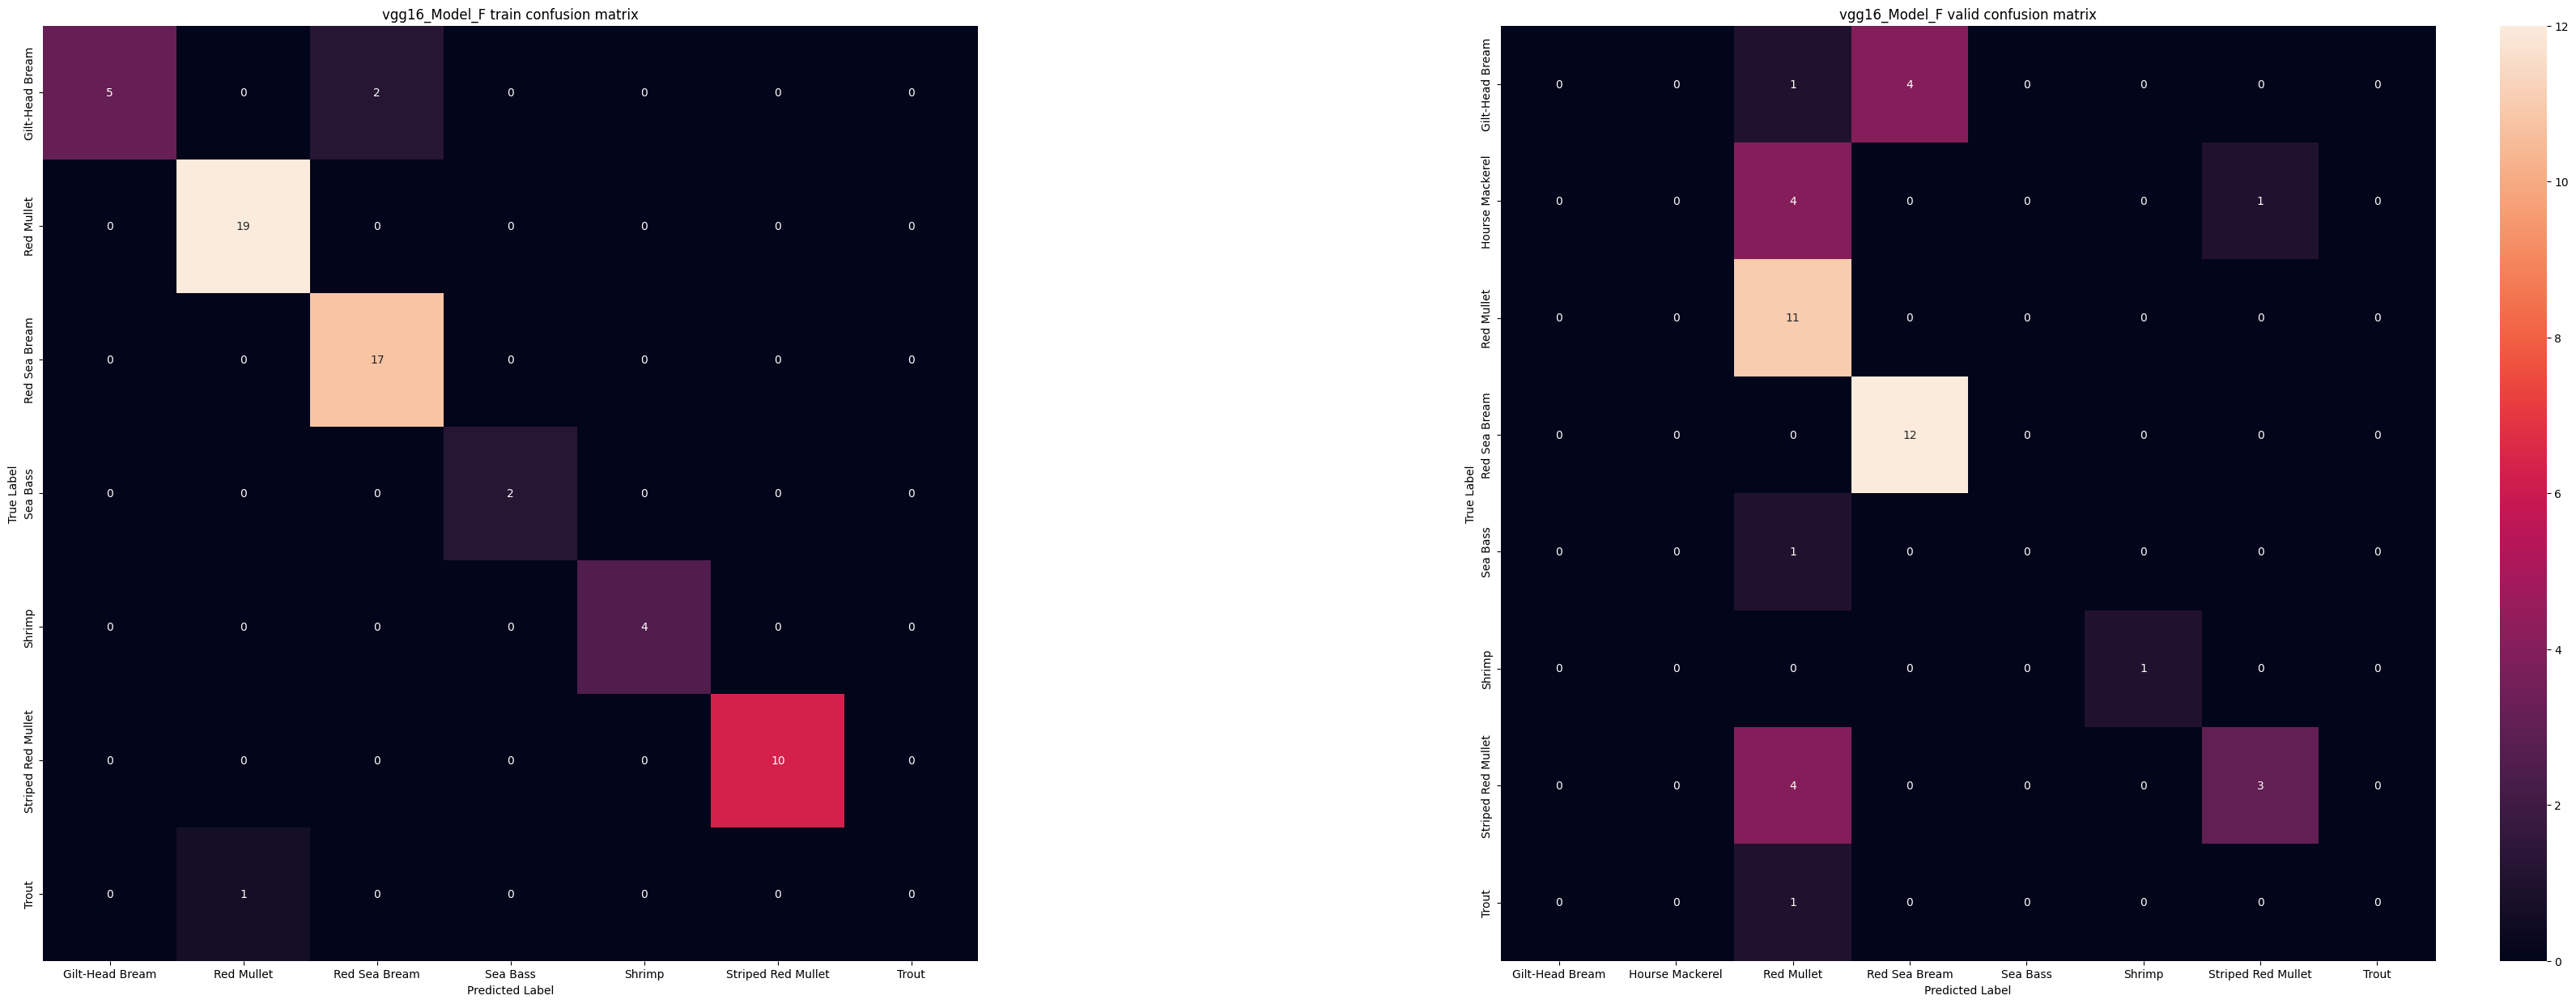

In [42]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [43]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
        
                if(softmax_decision>0.9):

                    if(pred_decision==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                    if(softmax_F>softmax_T):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [44]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.0012387177314857128, 0.9996825396825397, 57, 12543)

In [45]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.03120138536287457, 0.9944444444444445, 11, 3589)

In [46]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [47]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,1221,0,7,0,0,0.521192,1.0,0.999988,1.000000,False,True,True,True,True
1,17265,8,3,8,8,0.577737,1.0,1.000000,1.000000,False,True,True,True,True
2,3219,1,4,1,1,0.534303,1.0,0.999948,0.999352,False,True,True,True,True
3,12797,6,6,6,6,0.952719,1.0,1.000000,1.000000,True,True,True,True,True
4,17955,8,7,8,8,0.443171,1.0,0.999990,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12595,1046,0,7,0,0,0.559170,1.0,0.999998,1.000000,False,True,True,True,True
12596,11747,5,3,5,5,0.804985,1.0,0.999272,0.999999,False,True,True,True,True
12597,7679,3,3,3,3,0.823626,1.0,0.999891,1.000000,True,True,True,True,True
12598,9534,4,4,4,4,0.999260,1.0,0.999982,0.999999,True,True,True,True,True


In [48]:
len(df_results[(df_results['Decision']!=df_results['flag'])&(df_results['Softmax_decision']<0.9)])

21

In [49]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
216,14253,7,7,7,7,0.995328,1.000000,0.999987,0.605075,True,True,True,False,True
254,7721,3,3,3,3,0.955817,0.999770,0.979452,0.712150,True,True,True,False,True
383,7734,3,3,3,3,0.953782,0.999879,0.984614,0.753294,True,True,True,True,True
389,15647,7,7,7,7,0.789172,0.999931,0.999923,0.673464,True,True,True,True,True
656,2106,1,1,1,1,0.999997,1.000000,0.999405,0.807114,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11694,7523,3,3,3,3,0.968401,0.999996,0.800768,0.897419,True,True,True,True,True
11873,9553,4,4,4,4,0.998136,1.000000,0.964952,0.509741,True,True,True,False,False
11984,7395,3,3,3,3,0.937630,0.999782,0.808859,0.599021,True,True,True,False,True
12313,7001,3,3,3,3,0.966865,0.999993,0.978498,0.823255,True,True,True,True,True


In [50]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
67,14333,7,7,7,7,0.998067,1.000000,0.999982,0.990741,True,True,True,False,True
130,7119,3,3,3,3,0.978371,0.999802,0.945785,0.974211,True,True,True,False,True
216,14253,7,7,7,7,0.995328,1.000000,0.999987,0.605075,True,True,True,False,True
254,7721,3,3,3,3,0.955817,0.999770,0.979452,0.712150,True,True,True,False,True
366,14891,7,7,7,7,0.989087,1.000000,0.999428,0.998763,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11746,7426,3,3,3,7,0.922438,0.999945,0.790584,0.961386,True,True,False,False,True
11896,15121,7,3,7,7,0.520202,0.999987,0.680187,0.997281,False,True,True,False,True
11984,7395,3,3,3,3,0.937630,0.999782,0.808859,0.599021,True,True,True,False,True
12367,14371,7,7,7,7,0.985245,1.000000,0.999233,0.981461,True,True,True,False,True


In [51]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

4    24
3    18
7    15
1     5
6     4
8     1
5     1
Name: Target, dtype: int64

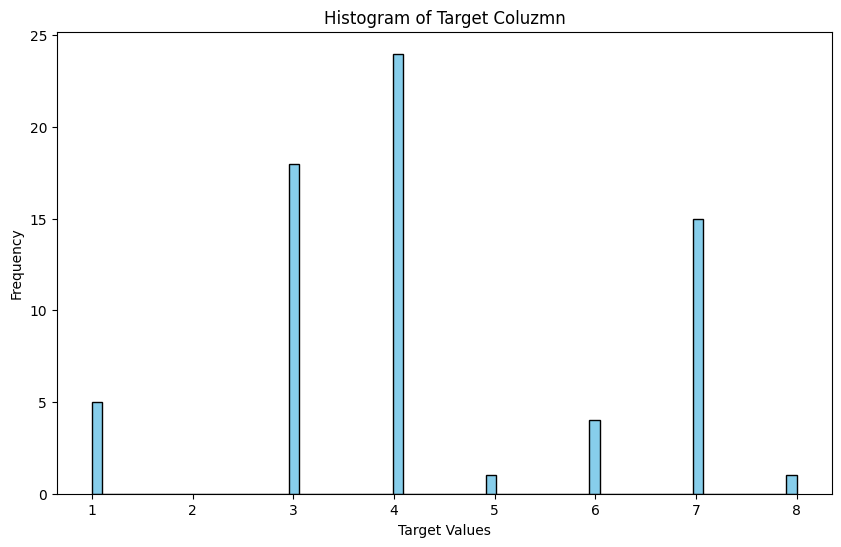

In [52]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [53]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,2071,1,1,1,1,0.758556,1.000000,0.999998,1.000000,True,True,True,True,True
1,8064,4,4,4,4,0.987881,1.000000,0.999995,1.000000,True,True,True,True,True
2,11561,5,3,5,5,0.864744,1.000000,0.999998,1.000000,False,True,True,True,True
3,14629,7,7,7,7,0.990937,1.000000,1.000000,1.000000,True,True,True,True,True
4,3452,1,1,1,1,0.664943,0.999965,0.999972,1.000000,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,17507,8,7,8,8,0.533677,1.000000,1.000000,1.000000,False,True,True,True,True
3596,14920,7,7,7,7,0.993576,1.000000,0.999998,1.000000,True,True,True,True,True
3597,13029,6,6,6,6,0.930036,1.000000,0.999890,1.000000,True,True,True,True,True
3598,7375,3,3,3,3,0.964999,0.900211,0.887900,0.999853,True,True,True,False,False


In [54]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,9291,4,4,4,4,0.998492,1.000000,0.995148,0.709653,True,True,True,False,True
133,3807,1,4,4,1,0.957836,0.795055,0.756421,1.000000,False,False,True,True,False
229,15450,7,3,7,5,0.552646,0.975445,0.637435,0.999983,False,True,False,True,False
316,7414,3,3,3,7,0.956837,0.999993,0.507093,0.999974,True,True,False,True,False
421,17835,8,3,8,3,0.984464,0.692850,0.545584,0.999837,False,True,False,True,False
571,11305,5,3,5,5,0.617001,0.999016,0.995048,1.000000,False,True,True,True,False
758,5218,2,1,2,2,0.486501,0.999981,0.999992,1.000000,False,True,True,True,False
774,9014,4,4,1,1,0.696585,0.782528,0.956753,0.908811,True,False,False,True,False
965,13711,6,6,6,0,0.988777,0.999909,0.579120,0.998978,True,True,False,True,False
1210,7367,3,3,3,7,0.923871,0.968923,0.829471,0.995654,True,True,False,True,False


In [55]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

4    17
3    11
1     6
7     6
2     5
5     2
8     1
6     1
Name: Target, dtype: int64

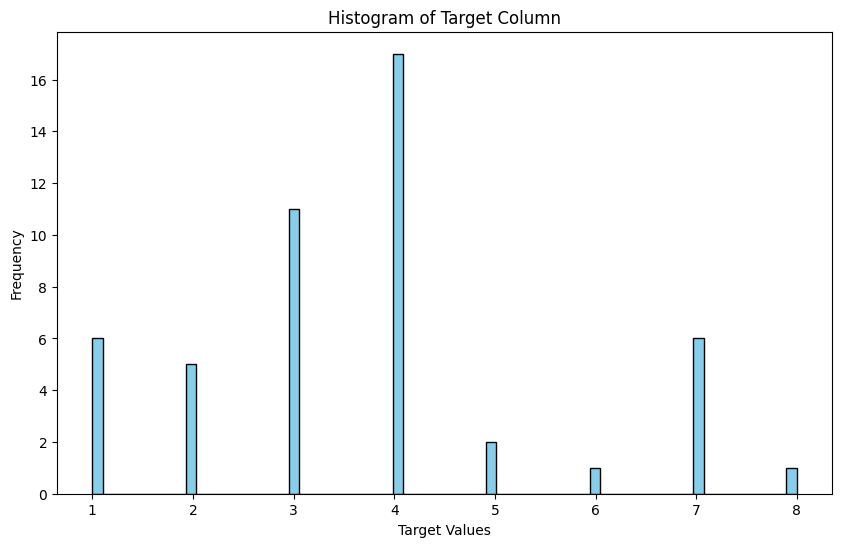

In [56]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()